# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [21]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [22]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.30198988800000004
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999999
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


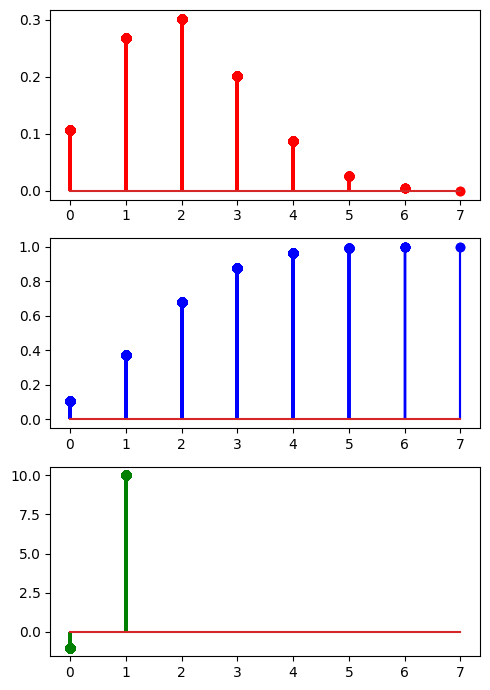

In [23]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

Densidad x=1 N(0,1): 0.24197072451914337
Probabilidad acumulada x=1 for N(0,1): 0.8413447460685429
Valor con una probabilidad acumulada N(0,1): 1.2815515655446004
Muestra aleatorio 2000 valores de N(0,1): [ 0.49671415 -0.1382643   0.64768854 ... -0.88187465 -0.16306696
 -0.74490264]


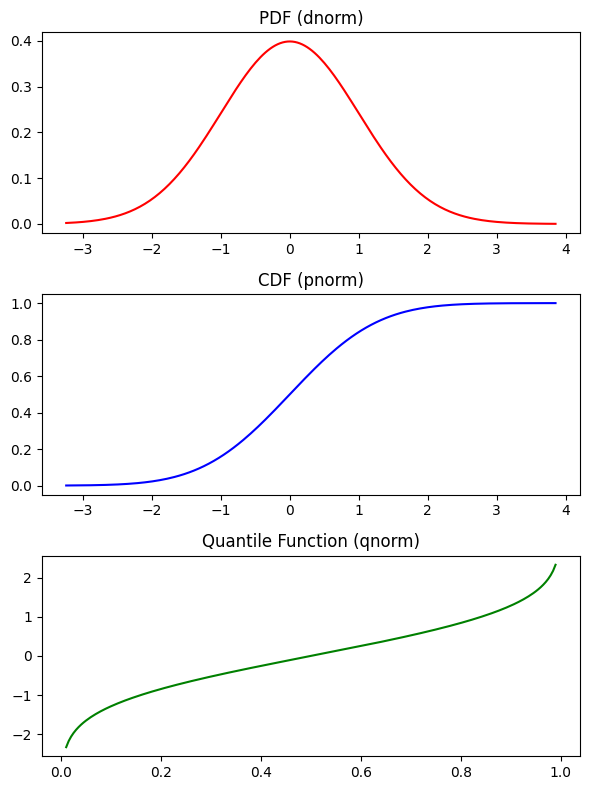

Densidad x=0.5 para U(0,1): 1.0
Probabilidad acumulada x=0.5 for U(0,1): 0.5
Valor con una probabilidad acumulada de 0.9 en U(0,1): 0.9
Muestra aleatoria de 2000 valores de U(0,1): [0.37454012 0.95071431 0.73199394 ... 0.06895802 0.05705472 0.28218707]


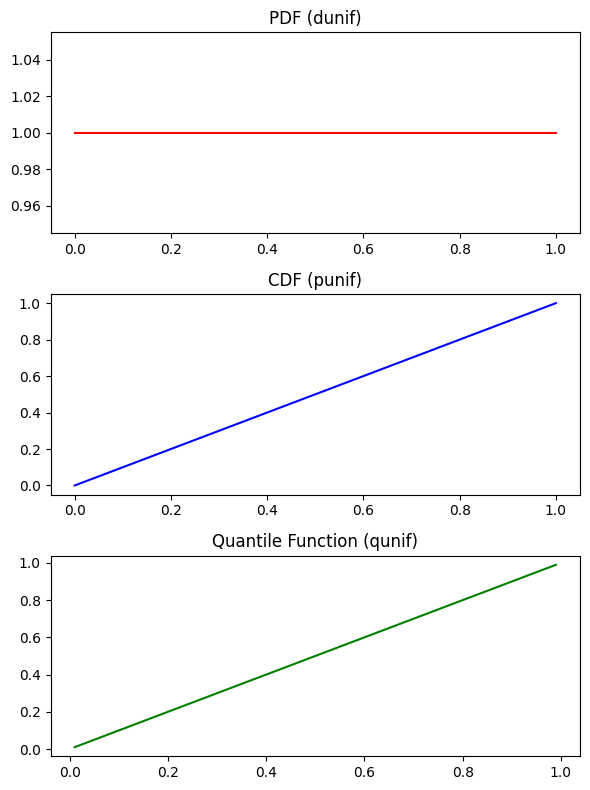

In [24]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt 

#Funciones normales

def dnorm(x, mean=0, sd=1):
    return norm.pdf(x, loc=mean, scale=sd)

def pnorm(q, mean=0, sd=1):
    return norm.cdf(q, loc=mean, scale=sd)

def qnorm(p, mean=0, sd=1):
    return norm.ppf(p, loc=mean, scale=sd)

def rnorm(n, mean=0, sd=1):
    return norm.rvs(loc=mean, scale=sd, size=n)

np.random.seed(42)

print(f"Densidad x=1 N(0,1): {dnorm(1)}")
print(f"Probabilidad acumulada x=1 for N(0,1): {pnorm(1)}")
print(f"Valor con una probabilidad acumulada N(0,1): {qnorm(0.9)}")
print(f"Muestra aleatorio 2000 valores de N(0,1): {rnorm(2000)}")

np.random.seed(42)
mean = 0
sd = 1
data = rnorm(2000, mean=mean, sd=sd)

x = np.linspace(min(data), max(data), 200)

pdf = dnorm(x, mean=mean, sd=sd)
cdf = pnorm(x, mean=mean, sd=sd)
ppf = qnorm(np.linspace(0.01, 0.99, len(x)), mean=mean, sd=sd)  # evita extremos 0 y 1

fig, axis = plt.subplots(3, 1, figsize=(6, 8))

axis[0].plot(x, pdf, 'r-')
axis[0].set_title('PDF (dnorm)')
axis[1].plot(x, cdf, 'b-')
axis[1].set_title('CDF (pnorm)')
axis[2].plot(np.linspace(0.01, 0.99, len(x)), ppf, 'g-')
axis[2].set_title('Quantile Function (qnorm)')

plt.tight_layout()
plt.show()

#Para Uniformes

from scipy.stats import uniform
import numpy as np
import matplotlib.pyplot as plt

def dunif(x, min_=0, max_=1):
    return uniform.pdf(x, loc=min_, scale=max_ - min_)

def punif(q, min_=0, max_=1):
    return uniform.cdf(q, loc=min_, scale=max_ - min_)

def qunif(p, min_=0, max_=1):
    return uniform.ppf(p, loc=min_, scale=max_ - min_)

def runif(n, min_=0, max_=1):
    return uniform.rvs(loc=min_, scale=max_ - min_, size=n)

np.random.seed(42)

print(f"Densidad x=0.5 para U(0,1): {dunif(0.5)}")
print(f"Probabilidad acumulada x=0.5 for U(0,1): {punif(0.5)}")
print(f"Valor con una probabilidad acumulada de 0.9 en U(0,1): {qunif(0.9)}")
print(f"Muestra aleatoria de 2000 valores de U(0,1): {runif(2000)}")

np.random.seed(42)
min_ = 0
max_ = 1
data = runif(2000, min_, max_)

x = np.linspace(min_, max_, 200)

pdf = dunif(x, min_, max_)
cdf = punif(x, min_, max_)
ppf = qunif(np.linspace(0.01, 0.99, len(x)), min_, max_)

fig, axis = plt.subplots(3, 1, figsize=(6, 8))

axis[0].plot(x, pdf, 'r-')
axis[0].set_title('PDF (dunif)')
axis[1].plot(x, cdf, 'b-')
axis[1].set_title('CDF (punif)')
axis[2].plot(np.linspace(0.01, 0.99, len(x)), ppf, 'g-')
axis[2].set_title('Quantile Function (qunif)')

plt.tight_layout()
plt.show()